In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from tensorflow.keras.datasets import mnist
import numpy as np
import random


In [7]:
# Load and preprocess the MNIST dataset
(x_train, y_train), (_, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_train = np.expand_dims(x_train, axis=1)  # Add channel dimension
x_train = torch.tensor(x_train, dtype=torch.float32)

# Define a custom dataset for SSL with rotation prediction
class RotationDataset(Dataset):
    def __init__(self, images):
        self.images = images
        self.transform = transforms.Compose([transforms.ToTensor()])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        # Apply a random rotation
        angles = [0, 90, 180, 270]
        angle = random.choice(angles)
        rotated_image = transforms.functional.rotate(image, angle)
        label = angles.index(angle)  # Label is the index of the rotation angle
        return rotated_image, label

# Create a DataLoader for the SSL task
ssl_dataset = RotationDataset(x_train)
ssl_loader = DataLoader(ssl_dataset, batch_size=64, shuffle=True)


In [8]:
# Define the CNN model for SSL
class SSLModel(nn.Module):
    def __init__(self):
        super(SSLModel, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Linear(64 * 7 * 7, 4)  # 4 classes for rotation angles

    def forward(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Instantiate the model, loss function, and optimizer
ssl_model = SSLModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ssl_model.parameters(), lr=0.001)


In [9]:
# Pretrain the model on the rotation prediction task
for epoch in range(5):
    for images, labels in ssl_loader:
        optimizer.zero_grad()
        outputs = ssl_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}, SSL Loss: {loss.item()}')


Epoch 1, SSL Loss: 0.0177924782037735
Epoch 2, SSL Loss: 0.002610705327242613
Epoch 3, SSL Loss: 0.006071374285966158
Epoch 4, SSL Loss: 0.00020944312564097345
Epoch 5, SSL Loss: 0.05360963195562363


In [10]:
# Fine-tune the model for digit classification
# Load the labeled MNIST dataset
y_train = torch.tensor(y_train, dtype=torch.long)
train_dataset = torch.utils.data.TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Modify the model for digit classification
ssl_model.classifier = nn.Linear(64 * 7 * 7, 10)  # 10 classes for digits
optimizer = optim.Adam(ssl_model.parameters(), lr=0.001)

# Fine-tune the model
for epoch in range(5):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = ssl_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}, Classification Loss: {loss.item()}')

Epoch 1, Classification Loss: 0.005351909436285496
Epoch 2, Classification Loss: 0.005114029627293348
Epoch 3, Classification Loss: 0.0491194911301136
Epoch 4, Classification Loss: 0.053686000406742096
Epoch 5, Classification Loss: 0.034475553780794144


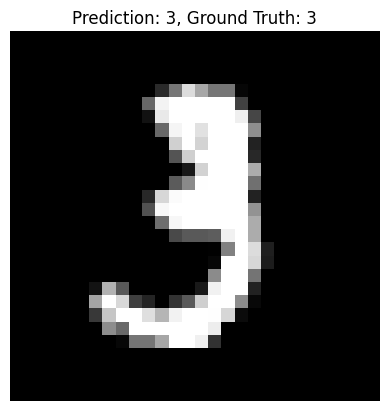

In [14]:
import matplotlib.pyplot as plt

# Select one example from the dataset
example_idx = 10  # Change this index to test different examples
example_image = x_train[example_idx].unsqueeze(0)  # Add batch dimension
ground_truth = y_train[example_idx].item()

# Ensure the model is in evaluation mode
ssl_model.eval()

# Perform prediction
with torch.no_grad():
    output = ssl_model(example_image)
    prediction = torch.argmax(output, dim=1).item()

# Display the image, prediction, and ground truth
plt.imshow(example_image.squeeze(0).squeeze(0), cmap='gray')  # Remove batch and channel dimensions
plt.title(f"Prediction: {prediction}, Ground Truth: {ground_truth}")
plt.axis('off')
plt.show()